# EE 446 TinyML — Model Pruning with Quantization  
## Student TODO Version: Pruning and Quantization of a DNN Using the UCI Human Activity Recognition Dataset

### Overview
In this notebook, you will:
- train a baseline DNN on the **UCI HAR** dataset,
- apply **magnitude-based pruning**,
- compare the pruned model before and after `strip_pruning(...)`, and
- combine pruning with **float16 quantization**.

Use the **`Python (tinyml-arduino)`** Jupyter kernel for this notebook.


## 1. Environment Setup

This notebook is designed to run with the **`Python (tinyml-arduino)`** Jupyter kernel that you already created.

This notebook assumes the environment already contains:
- `tensorflow==2.14.1`
- `tensorflow-model-optimization==0.8.0`
- `numpy`, `pandas`, `matplotlib`, and `scikit-learn`

Do **not** reinstall TensorFlow packages inside the notebook if you are already using the working TinyML environment.


In [7]:
import os
import math
import zipfile
import random
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from pathlib import Path
import tensorflow_model_optimization as tfmot

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Python executable:", os.sys.executable)
print("TensorFlow version:", tf.__version__)
print("TF-MOT version:", tfmot.__version__)


Python executable: /Users/y/ai/projects/tinyml-arduino/bin/python
TensorFlow version: 2.14.1
TF-MOT version: 0.8.0


## 2. Download and Extract the UCI HAR Dataset

The original dataset contains:
- **561 numerical features** extracted from smartphone sensor signals,
- **6 activity classes**, and
- predefined **training** and **test** splits.

The code below downloads and extracts the dataset if it is not already present in the working directory.


In [8]:

dataset_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
zip_path = Path("uci_har_dataset.zip")
extract_dir = Path(".")

if not zip_path.exists():
    print("Downloading dataset...")
    urllib.request.urlretrieve(dataset_url, zip_path)

dataset_root = Path("UCI HAR Dataset")
if not dataset_root.exists():
    print("Extracting dataset...")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)

print("Dataset ready at:", dataset_root.resolve())


Dataset ready at: /Users/y/Desktop/446/lab3/UCI HAR Dataset


## 3. Load the Data

In [9]:

def load_har_data(root_dir="UCI HAR Dataset"):
    root_dir = Path(root_dir)

    # TODO:
    # 1. Load X_train from train/X_train.txt as float32
    # 2. Load y_train from train/y_train.txt as int32 and subtract 1
    # 3. Load X_test from test/X_test.txt as float32
    # 4. Load y_test from test/y_test.txt as int32 and subtract 1

    X_train = np.loadtxt(os.path.join(root_dir, "train", "X_train.txt"))
    y_train = np.loadtxt(os.path.join(root_dir, "train", "y_train.txt")).astype(int) - 1

    X_test = np.loadtxt(os.path.join(root_dir, "test", "X_test.txt"))
    y_test = np.loadtxt(os.path.join(root_dir, "test", "y_test.txt")).astype(int) - 1


    return X_train, y_train, X_test, y_test

X_train, y_train, X_test, y_test = load_har_data()

class_names = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING",
]

num_features = X_train.shape[1]
num_classes = len(class_names)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape :", X_test.shape)
print("y_test shape :", y_test.shape)
print("Number of features:", num_features)
print("Number of classes :", num_classes)


X_train shape: (7352, 561)
y_train shape: (7352,)
X_test shape : (2947, 561)
y_test shape : (2947,)
Number of features: 561
Number of classes : 6


## 4. Quick Inspection

In [10]:
# TODO:
# Create a small summary table showing:
# - class index,
# - class name, and
# - number of training samples in each class.

# <-- Enter your code here <--#

label_counts = pd.Series(y_train).value_counts().sort_index()

dataset_summary = pd.DataFrame({
    "Class Index": list(range(num_classes)),
    "Class Name": class_names,
    "Training Samples": label_counts.values,
})

dataset_summary


,Class Index,Class Name,Training Samples
0,0,WALKING,1226
1,1,WALKING_UPSTAIRS,1073
2,2,WALKING_DOWNSTAIRS,986
3,3,SITTING,1286
4,4,STANDING,1374
5,5,LAYING,1407


## 5. Train a Baseline DNN

We will use a compact dense neural network that is appropriate for a numerical-feature TinyML workflow.

### Architecture
- Input: 561 features
- Dense(256, ReLU)
- Dense(128, ReLU)
- Dense(64, ReLU)
- Dense(6, Softmax)


In [12]:
def build_baseline_model(input_dim, num_classes):
    # TODO:
    # Build and compile a DNN with the following architecture:
    # Input -> Dense(256, relu) -> Dense(128, relu) -> Dense(64, relu) -> Dense(num_classes, softmax)
    # Use Adam with learning rate 1e-3.
    # Use sparse_categorical_crossentropy as the loss.
    # Track accuracy as a metric.

    # <-- Enter your code here <--#
    inputs = keras.Input(shape=(input_dim,))
    x = layers.Dense(256, activation='relu')(inputs)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dense(64, activation='relu')(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs=inputs, outputs=outputs)

    model.compile(
        optimizer = keras.optimizers.Adam(learning_rate=1e-3),
        loss = 'sparse_categorical_crossentropy',
        metrics = ['accuracy'],
    )
    return model
    
    #raise NotImplementedError("Complete the baseline DNN.")

baseline_model = build_baseline_model(num_features, num_classes)
baseline_model.summary()


Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 561)]             0         
                                                                 
 dense_4 (Dense)             (None, 256)               143872    
                                                                 
 dense_5 (Dense)             (None, 128)               32896     
                                                                 
 dense_6 (Dense)             (None, 64)                8256      
                                                                 
 dense_7 (Dense)             (None, 6)                 390       
                                                                 
Total params: 185414 (724.27 KB)
Trainable params: 185414 (724.27 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


### Train the Baseline Model

In [13]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True
    )
]

# TODO:
# Train the baseline model using:
# - validation_split=0.2
# - epochs=40
# - batch_size=64
# - callbacks=callbacks

history = baseline_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=40,
    batch_size=64,
    callbacks=callbacks,

    
)

Epoch 1/40
92/92 [==============================] - 1s 3ms/step - loss: 0.4751 - accuracy: 0.8067 - val_loss: 0.2226 - val_accuracy: 0.9218
Epoch 2/40
92/92 [==============================] - 0s 2ms/step - loss: 0.1763 - accuracy: 0.9340 - val_loss: 0.1587 - val_accuracy: 0.9293
Epoch 3/40
92/92 [==============================] - 0s 2ms/step - loss: 0.1155 - accuracy: 0.9544 - val_loss: 0.4448 - val_accuracy: 0.8736
Epoch 4/40
92/92 [==============================] - 0s 2ms/step - loss: 0.0986 - accuracy: 0.9590 - val_loss: 0.1830 - val_accuracy: 0.9341
Epoch 5/40
92/92 [==============================] - 0s 2ms/step - loss: 0.0853 - accuracy: 0.9660 - val_loss: 0.2207 - val_accuracy: 0.9198
Epoch 6/40
92/92 [==============================] - 0s 2ms/step - loss: 0.0706 - accuracy: 0.9711 - val_loss: 0.2616 - val_accuracy: 0.9205
Epoch 7/40
92/92 [==============================] - 0s 2ms/step - loss: 0.0669 - accuracy: 0.9738 - val_loss: 0.1493 - val_accuracy: 0.9436
Epoch 8/40
92/92 [==

### Training Curves

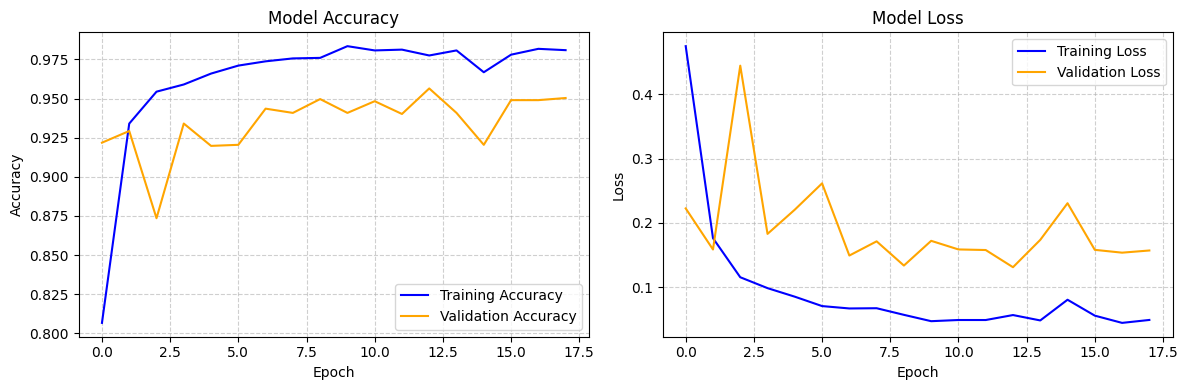

In [14]:
# TODO:
# Plot:
# 1. training accuracy vs validation accuracy
# 2. training loss vs validation loss

# <-- Enter your code here <--#
# TODO:
# Plot the training and validation accuracy.
# Plot the training and validation loss.

# <-- Enter your code here <--#
# Set up a wider figure to hold two plots side-by-side
plt.figure(figsize=(12, 4))

# --- Plot 1: Training and Validation Accuracy ---
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

# --- Plot 2: Training and Validation Loss ---
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## 6. Evaluate the Baseline Keras Model

93/93 [==============================] - 0s 740us/step
Test Accuracy: 0.9372

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.96      0.95       496
           1       0.91      0.94      0.92       471
           2       0.95      0.91      0.93       420
           3       0.96      0.85      0.90       491
           4       0.87      0.97      0.91       532
           5       1.00      0.99      0.99       537

    accuracy                           0.94      2947
   macro avg       0.94      0.94      0.94      2947
weighted avg       0.94      0.94      0.94      2947



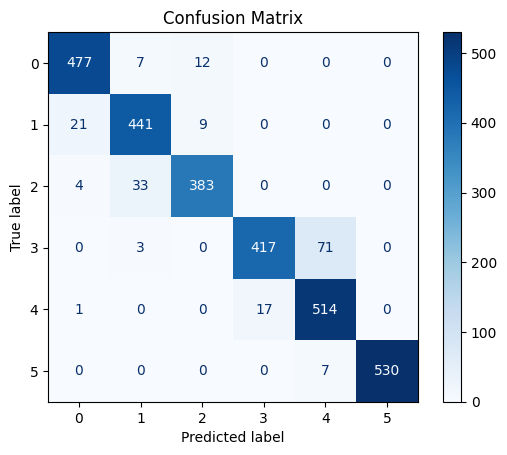

In [21]:
# TODO:
# 1. Predict class probabilities on X_test
# 2. Convert probabilities to class labels using argmax
# 3. Compute the test accuracy
# 4. Print the classification report
# 5. Plot the confusion matrix

# <-- Enter your code here <--#
predicted_prob = baseline_model.predict(X_test)

baseline_y_pred = np.argmax(predicted_prob, axis=1)

test_accuracy = accuracy_score(y_test, baseline_y_pred)
print(f"Test Accuracy: {test_accuracy:.4f}\n")

print("Classification Report:")
print(classification_report(y_test, baseline_y_pred))

cm = confusion_matrix(y_test, baseline_y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

# Plotting with a blue colormap for better readability
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()


# Part I: Model Pruning with Sparsity

In this part, we apply **magnitude-based pruning** to the DNN. The key idea is to gradually set small-magnitude weights to zero during training.

We will compare:
1. the baseline TensorFlow Lite model,
2. the pruned model converted **without** stripping the pruning wrappers, and
3. the stripped sparse model converted with **experimental sparsity-aware optimization**.


## 7. TensorFlow Lite Utilities

The following helper functions are used to:
- convert Keras models to TensorFlow Lite,
- evaluate TensorFlow Lite models on the test set, and
- measure model size.


In [22]:
def save_binary_model(model_content, filename):
    with open(filename, "wb") as f:
        f.write(model_content)
    return os.path.getsize(filename) / 1024.0  # KB

def evaluate_tflite_model(tflite_model, X, y_true):
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    input_scale, input_zero_point = input_details["quantization"]
    output_scale, output_zero_point = output_details["quantization"]

    y_pred = []

    for i in range(len(X)):
        x = X[i:i+1].astype(np.float32)

        # TODO:
        # Quantize the input only when the TFLite input tensor expects int8 or uint8.
        # Otherwise keep the input in the required floating-point dtype.

        # <-- Enter your code here <--#
        if input_details["dtype"] in [np.int8, np.uint8]:
            x = (x / input_scale) + input_zero_point
            x = np.round(x).astype(input_details["dtype"])
        else:
            x = x.astype(input_details['dtype'])
        interpreter.set_tensor(input_details["index"], x)
        interpreter.invoke()

        output = interpreter.get_tensor(output_details["index"])

        # TODO:
        # Dequantize the output only when the output tensor is int8 or uint8.

        # <-- Enter your code here <--#
        if input_details['dtype'] in [np.int8, np.uint8]:
            output = (output.astype(np.float32) - output_zero_point) * output_scale
        pred = int(np.argmax(output, axis=1)[0])
        y_pred.append(pred)

    acc = accuracy_score(y_true, y_pred)
    return acc, np.array(y_pred)

def convert_to_tflite_fp32(model):
    # TODO:
    # Create a TFLiteConverter from the Keras model and return the converted FP32 model bytes.

    # <-- Enter your code here <--#
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    return converter.convert()
    # raise NotImplementedError("Complete the FP32 conversion helper.")


## 8. Convert the Baseline Model to TensorFlow Lite

In [25]:
# TODO:
# Convert the baseline model to FP32 TensorFlow Lite.
# Save the .tflite file, compute its size in KB, and evaluate it on X_test.
baseline_fp32_tflite = convert_to_tflite_fp32(baseline_model)
baseline_fp32_tflite_kb = save_binary_model(baseline_fp32_tflite, 'baseline_fp32_tflife')
baseline_fp32_acc, baseline_fp32_preds = evaluate_tflite_model(baseline_fp32_tflite, X_test, y_test)

print(f"Baseline FP32 Model accuracy: {baseline_fp32_acc:.4f}")
print(f"Baseline FP32 Model size (KB): {baseline_fp32_tflite_kb:.2f}")



INFO:tensorflow:Assets written to: /var/folders/v_/3b54zs4d6bbf222t0xyybss00000gn/T/tmpcmdn5nrv/assets


INFO:tensorflow:Assets written to: /var/folders/v_/3b54zs4d6bbf222t0xyybss00000gn/T/tmpcmdn5nrv/assets
2026-04-20 12:13:12.942134: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-20 12:13:12.942146: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-20 12:13:12.942237: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/v_/3b54zs4d6bbf222t0xyybss00000gn/T/tmpcmdn5nrv
2026-04-20 12:13:12.942777: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-20 12:13:12.942781: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/v_/3b54zs4d6bbf222t0xyybss00000gn/T/tmpcmdn5nrv
2026-04-20 12:13:12.944116: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-20 12:13:12.967118: I tensorflow/cc/saved_model/loader.cc:217] Running initialization

Baseline FP32 Model accuracy: 0.9372
Baseline FP32 Model size (KB): 726.66


## 9. Apply Magnitude-Based Pruning

We will prune the DNN using a **polynomial decay schedule**:
- start from low sparsity,
- gradually increase sparsity during training, and
- finish with a highly sparse model.

After training, we will compare:
- the pruned model **with** the pruning wrappers still present, and
- the final sparse model after applying `strip_pruning(...)`.


In [30]:
from tensorflow_model_optimization.sparsity.keras import (
    prune_low_magnitude,
    PolynomialDecay,
    UpdatePruningStep,
    strip_pruning
)

pruning_epochs = 12
batch_size = 64

# TODO:
# Compute steps_per_epoch using 80% of the training set and the selected batch size.
# Define pruning_params using PolynomialDecay with:
# - initial_sparsity=0.20
# - final_sparsity=0.85
# - begin_step=0
# - end_step=steps_per_epoch * pruning_epochs
steps_per_epoch = math.ceil((0.8 * len(X_train)) / batch_size)

# <-- Enter your code here <--#
pruning_params = {
    "pruning_schedule": PolynomialDecay(
        initial_sparsity=0.20,
        final_sparsity=0.85,
        begin_step=0,
        end_step=steps_per_epoch * pruning_epochs,
    )
}


# TODO:
# Create the pruned model by wrapping a fresh baseline DNN with prune_low_magnitude.
# Compile it with Adam(1e-3), sparse_categorical_crossentropy, and accuracy.

pruned_distilled_model = prune_low_magnitude(
    baseline_model, 
    **pruning_params
)

pruned_distilled_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)


# <-- Enter your code here <--#

pruning_callbacks = [
    UpdatePruningStep(),
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

# TODO:
# Train the pruned model using:
# - validation_split=0.2
# - epochs=pruning_epochs
# - batch_size=batch_size
# - callbacks=pruning_callbacks

# <-- Enter your code here <--#
pruning_history = pruned_distilled_model.fit(
    #<--- Enter your code here --->#
    X_train,
    y_train,
    validation_split = 0.2,
    epochs=pruning_epochs,
    batch_size=batch_size,
    callbacks=pruning_callbacks,
    verbose=1
)

Epoch 1/12
92/92 [==============================] - 1s 3ms/step - loss: 0.0318 - accuracy: 0.9895 - val_loss: 0.1260 - val_accuracy: 0.9538
Epoch 2/12
92/92 [==============================] - 0s 2ms/step - loss: 0.0324 - accuracy: 0.9893 - val_loss: 0.1149 - val_accuracy: 0.9558
Epoch 3/12
92/92 [==============================] - 0s 3ms/step - loss: 0.0324 - accuracy: 0.9900 - val_loss: 0.1109 - val_accuracy: 0.9572
Epoch 4/12
92/92 [==============================] - 0s 3ms/step - loss: 0.0343 - accuracy: 0.9908 - val_loss: 0.1110 - val_accuracy: 0.9579
Epoch 5/12
92/92 [==============================] - 0s 3ms/step - loss: 0.0395 - accuracy: 0.9891 - val_loss: 0.1106 - val_accuracy: 0.9579
Epoch 6/12
92/92 [==============================] - 0s 3ms/step - loss: 0.0566 - accuracy: 0.9864 - val_loss: 0.1145 - val_accuracy: 0.9572
Epoch 7/12
92/92 [==============================] - 0s 3ms/step - loss: 0.2516 - accuracy: 0.9371 - val_loss: 0.1538 - val_accuracy: 0.9456


## 10. Convert the Pruned Model Before and After Stripping the Pruning Wrappers

First, we convert the pruned model **with** the pruning wrappers still attached.

Next, we strip the pruning wrappers and convert the resulting sparse model with:
- `tf.lite.Optimize.EXPERIMENTAL_SPARSITY`

This is the proper way to preserve sparsity in the exported TensorFlow Lite model.


In [31]:
# TODO:
# 1. Convert the pruned model WITH the pruning wrappers still attached to FP32 TensorFlow Lite.
# 2. Save the model and evaluate it on X_test.
# 3. Strip the pruning wrappers using strip_pruning(...).
# 4. Convert the stripped model with tf.lite.Optimize.EXPERIMENTAL_SPARSITY.
# 5. Save the stripped sparse model and evaluate it on X_test.

# <-- Enter your code here <--#

# TODO:
# Convert the pruned model with the pruning wrappers still attached.
pruned_with_mask_tflite = convert_to_tflite_fp32(pruned_distilled_model)
pruned_with_mask_size_kb = save_binary_model(pruned_with_mask_tflite, "pruned_distilled_with_mask_fp32.tflite")
pruned_with_mask_acc, pruned_with_mask_preds = evaluate_tflite_model(pruned_with_mask_tflite, X_test, y_test)

# TODO:
# Strip the pruning wrappers and convert again using sparse optimization.
stripped_pruned_model = strip_pruning(pruned_distilled_model)

converter = tf.lite.TFLiteConverter.from_keras_model(stripped_pruned_model)
converter.optimizations = [tf.lite.Optimize.EXPERIMENTAL_SPARSITY]
stripped_sparse_tflite = converter.convert()

stripped_sparse_size_kb = save_binary_model(stripped_sparse_tflite, "distilled_stripped_sparse_fp32.tflite")
stripped_sparse_acc, stripped_sparse_preds = evaluate_tflite_model(stripped_sparse_tflite, X_test, y_test)

print(f"Pruned distilled model with mask accuracy: {pruned_with_mask_acc:.4f}")
print(f"Pruned distilled model with mask size (KB): {pruned_with_mask_size_kb:.2f}")
print(f"Stripped sparse distilled model accuracy: {stripped_sparse_acc:.4f}")
print(f"Stripped sparse distilled model size (KB): {stripped_sparse_size_kb:.2f}")


INFO:tensorflow:Assets written to: /var/folders/v_/3b54zs4d6bbf222t0xyybss00000gn/T/tmpj86mj57j/assets


INFO:tensorflow:Assets written to: /var/folders/v_/3b54zs4d6bbf222t0xyybss00000gn/T/tmpj86mj57j/assets
2026-04-20 20:25:47.226554: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-20 20:25:47.226886: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-20 20:25:47.227184: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/v_/3b54zs4d6bbf222t0xyybss00000gn/T/tmpj86mj57j
2026-04-20 20:25:47.229038: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-20 20:25:47.229045: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/v_/3b54zs4d6bbf222t0xyybss00000gn/T/tmpj86mj57j
2026-04-20 20:25:47.234659: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-20 20:25:47.273501: I tensorflow/cc/saved_model/loader.cc:217] Running initialization

INFO:tensorflow:Assets written to: /var/folders/v_/3b54zs4d6bbf222t0xyybss00000gn/T/tmpx_mlgbrj/assets


INFO:tensorflow:Assets written to: /var/folders/v_/3b54zs4d6bbf222t0xyybss00000gn/T/tmpx_mlgbrj/assets


Pruned distilled model with mask accuracy: 0.9325
Pruned distilled model with mask size (KB): 1454.00
Stripped sparse distilled model accuracy: 0.9325
Stripped sparse distilled model size (KB): 424.77


2026-04-20 20:25:47.918099: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-20 20:25:47.918110: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-20 20:25:47.918196: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/v_/3b54zs4d6bbf222t0xyybss00000gn/T/tmpx_mlgbrj
2026-04-20 20:25:47.918535: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-20 20:25:47.918539: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/v_/3b54zs4d6bbf222t0xyybss00000gn/T/tmpx_mlgbrj
2026-04-20 20:25:47.919302: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-20 20:25:47.928570: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /var/folders/v_/3b54zs4d6bbf222t0xyybss00000gn/T/tmpx_mlgbrj
2026-04-

## 11. Part I Comparison: Accuracy and Model Size

In [32]:
# TODO:
# Create a comparison DataFrame for Part I with the columns:
# Model, Format, Test Accuracy, Model Size (KB)

# Include:
# - baseline FP32 TFLite
# - pruned FP32 TFLite with mask
# - stripped sparse FP32 TFLite

# <-- Enter your code here <--#
models = ['baseline_fp32', 'pruned_with_mask','stripped_pruned_model']
acc = [test_accuracy, pruned_with_mask_acc, stripped_sparse_acc]
dataset_summary = pd.DataFrame({
    "Models": models,
    'Format': ['FP32', 'FP32', 'FP32']
    "Test Accuracy": acc,
    "Model Size": [baseline_fp32_tflite_kb,pruned_with_mask_size_kb, stripped_sparse_size_kb ],
})

dataset_summary


,Models,Test Accuracy,Model Size
0,baseline_fp32,0.937224,726.660156
1,pruned_with_mask,0.932474,1454.000000
2,stripped_pruned_model,0.932474,424.769531


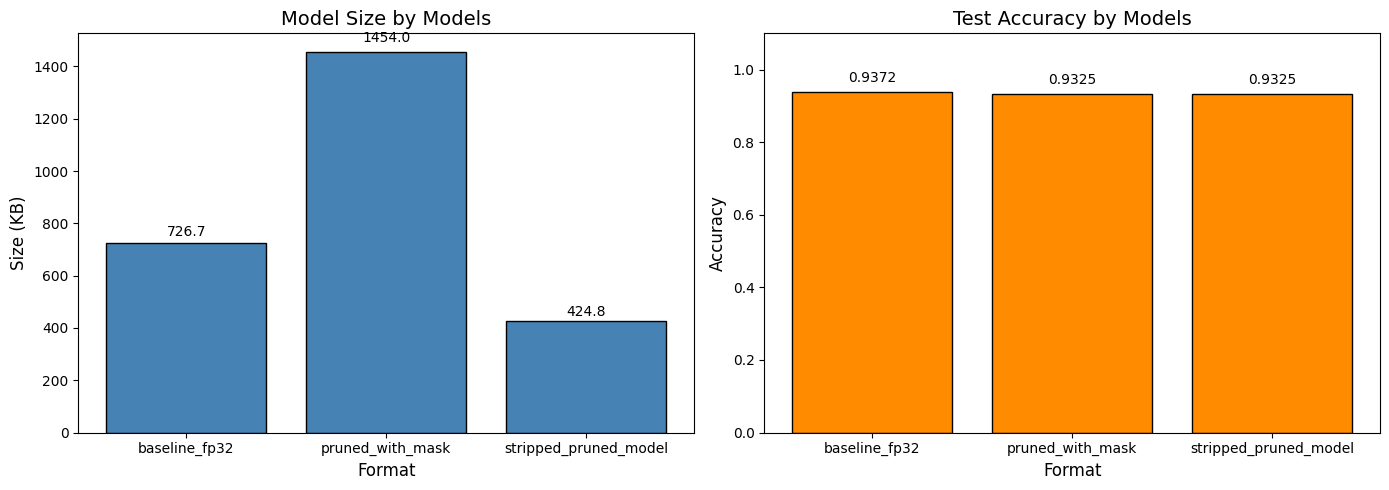

In [35]:
# TODO:
# Plot:
# 1. a bar chart of the Part I model sizes
# 2. a bar chart of the Part I test accuracies

# <-- Enter your code here <--#
# TODO:
# Create one bar plot for model size and another for test accuracy.

# <-- Enter your code here <--#
plt.figure(figsize=(14, 5))

# Plot 1: Model Size
plt.subplot(1, 2, 1)
bars_size = plt.bar(dataset_summary['Models'], dataset_summary['Model Size'], color='steelblue', edgecolor='black')
plt.title('Model Size by Models', fontsize=14)
plt.ylabel('Size (KB)', fontsize=12)
plt.xlabel('Format', fontsize=12)

# Add exact numbers on top of the bars for readability
for bar in bars_size:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + (yval * 0.02), f'{yval:.1f}', ha='center', va='bottom')

# Plot 2: Test Accuracy
plt.subplot(1, 2, 2)
bars_acc = plt.bar(dataset_summary['Models'], dataset_summary['Test Accuracy'], color='darkorange', edgecolor='black')
plt.title('Test Accuracy by Models', fontsize=14)
plt.ylabel('Accuracy', fontsize=12)
plt.xlabel('Format', fontsize=12)

# Set the y-axis limits to zoom in on the differences (assuming accuracy is around 0.5 - 1.0)
# We set the upper limit slightly above 1.0 to leave room for the text labels
plt.ylim(0, 1.1)

# Add exact numbers on top of the bars
for bar in bars_acc:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.4f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

### Confusion Matrix for the Stripped Sparse Model

Classification Report (Stripped Sparse):
              precision    recall  f1-score   support

           0       0.92      0.97      0.94       496
           1       0.93      0.90      0.91       471
           2       0.93      0.90      0.91       420
           3       0.95      0.87      0.91       491
           4       0.88      0.95      0.92       532
           5       1.00      0.98      0.99       537

    accuracy                           0.93      2947
   macro avg       0.93      0.93      0.93      2947
weighted avg       0.93      0.93      0.93      2947



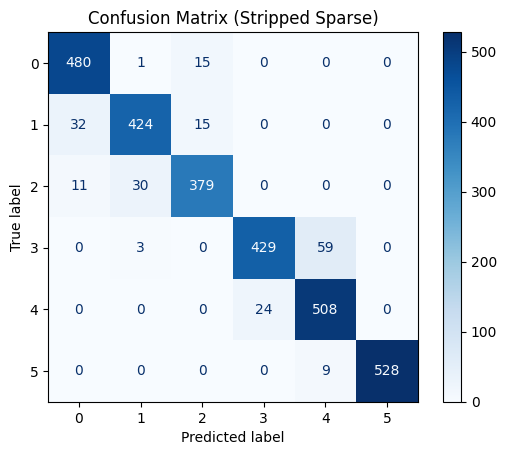

In [36]:
# TODO:
# Plot the confusion matrix for the stripped sparse TFLite model.
# Print the classification report for the stripped sparse TFLite model.

# <-- Enter your code here <--#
print("Classification Report (Stripped Sparse):")
print(classification_report(y_test, stripped_sparse_preds))

# 3. Plot the confusion matrix
cm_int8 = confusion_matrix(y_test, stripped_sparse_preds)
disp_int8 = ConfusionMatrixDisplay(confusion_matrix=cm_int8)

# Plotting with a green colormap to visually distinguish it from your baseline plot
disp_int8.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix (Stripped Sparse)")
plt.show()

# Part II: Model Pruning + Float16 Quantization

In this part, we combine **pruning** and **float16 quantization**.

We will compare:
1. the pruned TensorFlow Lite model **with** the pruning wrappers still attached, after float16 quantization, and
2. the stripped sparse TensorFlow Lite model after **both** sparsity-aware optimization and float16 quantization.

This lets us observe whether properly finalizing the pruned model leads to a more compact deployable representation.


In [39]:
# TODO:
# Part II: combine pruning and float16 quantization.
#
# 1. Convert the pruned model with mask using:
#    - optimizations = [tf.lite.Optimize.DEFAULT]
#    - supported_types = [tf.float16]
# 2. Save and evaluate the float16 model with mask.
# 3. Convert the stripped sparse model using:
#    - optimizations = [tf.lite.Optimize.DEFAULT, tf.lite.Optimize.EXPERIMENTAL_SPARSITY]
#    - supported_types = [tf.float16]
# 4. Save and evaluate the stripped sparse + float16 model.

# <-- Enter your code here <--#
def convert_to_fp16(keras_model):
    """
    Converts a Keras model to a Float16 quantized TensorFlow Lite model.
    
    Args:
        keras_model: The trained tf.keras.Model object to convert.
        output_filename (str, optional): The file path to save the .tflite model.
                                         If None, the model is only returned in memory.
                                         
    Returns:
        bytes: The converted TFLite model in byte format.
    """
    # Initialize the converter
    converter = tf.lite.TFLiteConverter.from_keras_model(keras_model)
    
    # Enable default optimizations and set target to Float16
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.target_spec.supported_types = [tf.float16]
    
    # Execute the conversion
    tflite_fp16_model = converter.convert()
    return tflite_fp16_model

# ==========================================
# 1. Pruned Model WITH Mask (FP16)
# ==========================================
pruned_with_mask_fp16 = convert_to_fp16(pruned_distilled_model)
pruned_with_mask_fp16_size_kb = save_binary_model(pruned_with_mask_fp16, "pruned_distilled_with_mask_fp16.tflite")

# Assuming evaluate_tflite_model takes the file path as the first argument
pruned_with_mask_fp16_acc, pruned_with_mask_fp16_preds = evaluate_tflite_model(pruned_with_mask_fp16, X_test, y_test)

# ==========================================
# 2. Stripped Sparse Model (FP16)
# ==========================================
# Ensure you have stripped the model first:
# stripped_pruned_model = tfmot.sparsity.keras.strip_pruning(pruned_distilled_model)

stripped_sparse_fp16 = convert_to_fp16(stripped_pruned_model) # SEE NOTE BELOW
stripped_sparse_fp16_size_kb = save_binary_model(stripped_sparse_fp16, "distilled_stripped_sparse_fp16.tflite")

# Assuming evaluate_tflite_model takes the file path as the first argument
stripped_sparse_fp16_acc, stripped_sparse_fp16_preds = evaluate_tflite_model(stripped_sparse_fp16, X_test, y_test)

# ==========================================
# 3. Print Results
# ==========================================
print(f"Pruned distilled model (FP16) with mask accuracy: {pruned_with_mask_fp16_acc:.4f}")
print(f"Pruned distilled model (FP16) with mask size (KB): {pruned_with_mask_fp16_size_kb:.2f}")
print(f"Stripped sparse distilled model (FP16) accuracy: {stripped_sparse_fp16_acc:.4f}")
print(f"Stripped sparse distilled model (FP16) size (KB): {stripped_sparse_fp16_size_kb:.2f}")


INFO:tensorflow:Assets written to: /var/folders/v_/3b54zs4d6bbf222t0xyybss00000gn/T/tmpadntwu_7/assets


INFO:tensorflow:Assets written to: /var/folders/v_/3b54zs4d6bbf222t0xyybss00000gn/T/tmpadntwu_7/assets
2026-04-20 20:49:03.923068: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-20 20:49:03.923080: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-20 20:49:03.923192: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/v_/3b54zs4d6bbf222t0xyybss00000gn/T/tmpadntwu_7
2026-04-20 20:49:03.925063: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-20 20:49:03.925073: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/v_/3b54zs4d6bbf222t0xyybss00000gn/T/tmpadntwu_7
2026-04-20 20:49:03.929584: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-20 20:49:03.963387: I tensorflow/cc/saved_model/loader.cc:217] Running initialization

INFO:tensorflow:Assets written to: /var/folders/v_/3b54zs4d6bbf222t0xyybss00000gn/T/tmp2m59_ips/assets


INFO:tensorflow:Assets written to: /var/folders/v_/3b54zs4d6bbf222t0xyybss00000gn/T/tmp2m59_ips/assets


Pruned distilled model (FP16) with mask accuracy: 0.9325
Pruned distilled model (FP16) with mask size (KB): 732.36
Stripped sparse distilled model (FP16) accuracy: 0.9325
Stripped sparse distilled model (FP16) size (KB): 365.62


2026-04-20 20:49:04.527862: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-20 20:49:04.527873: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-20 20:49:04.527962: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/v_/3b54zs4d6bbf222t0xyybss00000gn/T/tmp2m59_ips
2026-04-20 20:49:04.528304: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-20 20:49:04.528310: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/v_/3b54zs4d6bbf222t0xyybss00000gn/T/tmp2m59_ips
2026-04-20 20:49:04.529126: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-20 20:49:04.538632: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /var/folders/v_/3b54zs4d6bbf222t0xyybss00000gn/T/tmp2m59_ips
2026-04-

## 12. Part II Comparison: Accuracy and Model Size

In [41]:
# TODO:
# Create a Part II comparison DataFrame with the columns:
# Model, Format, Test Accuracy, Model Size (KB)
#
# Include:
# - pruned FP32 with mask
# - stripped sparse FP32
# - pruned float16 with mask
# - stripped sparse float16

# <-- Enter your code here <--#

models = ['pruned_with_mask','stripped_pruned_model','pruned_with_mask_fp16','stripped_pruned_model_fp16']
acc = [pruned_with_mask_acc, stripped_sparse_acc,pruned_with_mask_fp16_acc,stripped_sparse_fp16_acc]
dataset_summary = pd.DataFrame({
    "Models": models,
    'Format': ['FP32', 'FP32', 'FP16', 'FP16'],
    "Test Accuracy": acc,
    "Model Size": [pruned_with_mask_size_kb, stripped_sparse_size_kb, pruned_with_mask_fp16_size_kb,stripped_sparse_fp16_size_kb],
})

dataset_summary


,Models,Format,Test Accuracy,Model Size
0,pruned_with_mask,FP32,0.932474,1454.000000
1,stripped_pruned_model,FP32,0.932474,424.769531
2,pruned_with_mask_fp16,FP16,0.932474,732.363281
3,stripped_pruned_model_fp16,FP16,0.932474,365.621094


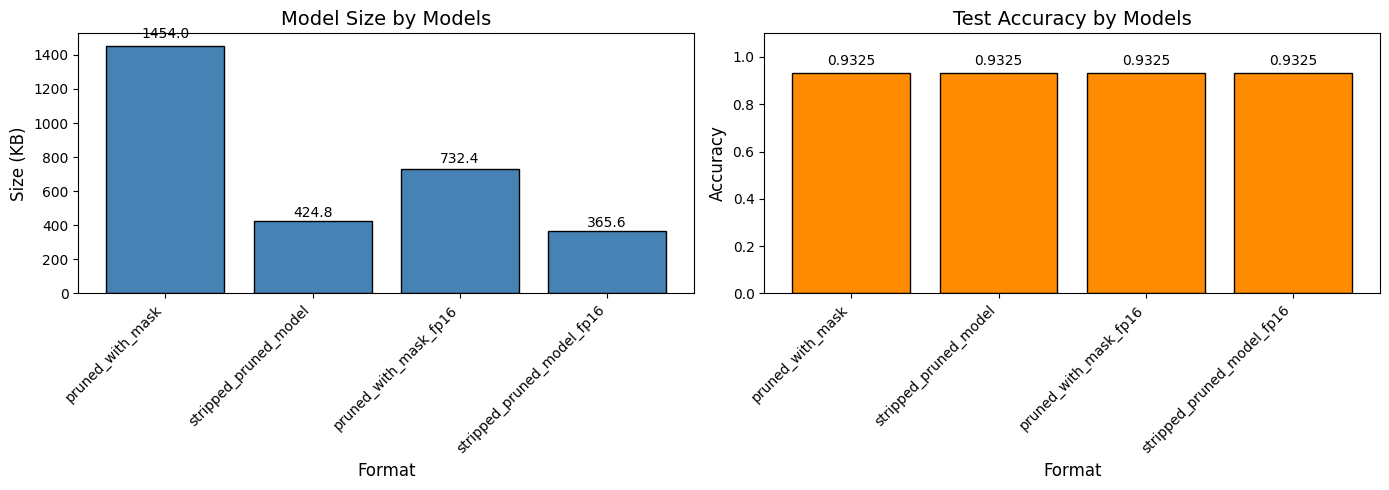

In [43]:
# TODO:
# Plot:
# 1. a bar chart of Part II model sizes
# 2. a bar chart of Part II test accuracies

# <-- Enter your code here <--#
# TODO:
# Plot:
# 1. a bar chart of the Part I model sizes
# 2. a bar chart of the Part I test accuracies

# <-- Enter your code here <--#
# TODO:
# Create one bar plot for model size and another for test accuracy.

# <-- Enter your code here <--#
plt.figure(figsize=(14, 5))

# Plot 1: Model Size
plt.subplot(1, 2, 1)
bars_size = plt.bar(dataset_summary['Models'], dataset_summary['Model Size'], color='steelblue', edgecolor='black')
plt.title('Model Size by Models', fontsize=14)
plt.ylabel('Size (KB)', fontsize=12)
plt.xlabel('Format', fontsize=12)
plt.xticks(rotation=45, ha='right') # Add this line
# Add exact numbers on top of the bars for readability
for bar in bars_size:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + (yval * 0.02), f'{yval:.1f}', ha='center', va='bottom')

# Plot 2: Test Accuracy
plt.subplot(1, 2, 2)
bars_acc = plt.bar(dataset_summary['Models'], dataset_summary['Test Accuracy'], color='darkorange', edgecolor='black')
plt.title('Test Accuracy by Models', fontsize=14)
plt.ylabel('Accuracy', fontsize=12)
plt.xlabel('Format', fontsize=12)
plt.xticks(rotation=45, ha='right') # Add this line
# Set the y-axis limits to zoom in on the differences (assuming accuracy is around 0.5 - 1.0)
# We set the upper limit slightly above 1.0 to leave room for the text labels
plt.ylim(0, 1.1)

# Add exact numbers on top of the bars
for bar in bars_acc:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.4f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

### Confusion Matrix for the Stripped Sparse + Float16 Model

Classification Report (Stripped Sparse+FP16):
              precision    recall  f1-score   support

           0       0.92      0.97      0.94       496
           1       0.93      0.90      0.91       471
           2       0.93      0.90      0.91       420
           3       0.95      0.87      0.91       491
           4       0.88      0.95      0.92       532
           5       1.00      0.98      0.99       537

    accuracy                           0.93      2947
   macro avg       0.93      0.93      0.93      2947
weighted avg       0.93      0.93      0.93      2947



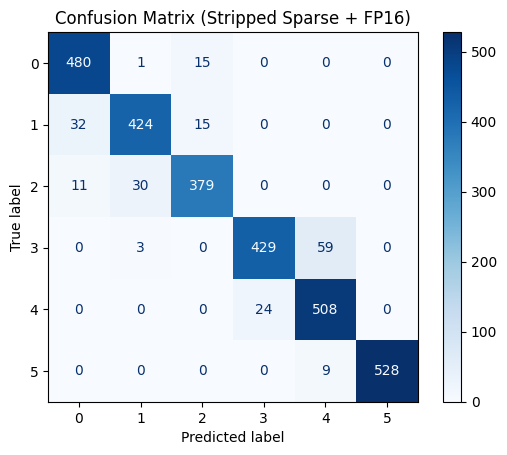

In [44]:
# TODO:
# Plot the confusion matrix for the stripped sparse + float16 TFLite model.
# Print the classification report for the stripped sparse + float16 TFLite model.

# <-- Enter your code here <--#

# <-- Enter your code here <--#
print("Classification Report (Stripped Sparse+FP16):")
print(classification_report(y_test, stripped_sparse_fp16_preds))

# 3. Plot the confusion matrix
cm_int8 = confusion_matrix(y_test, stripped_sparse_fp16_preds)
disp_int8 = ConfusionMatrixDisplay(confusion_matrix=cm_int8)

# Plotting with a green colormap to visually distinguish it from your baseline plot
disp_int8.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix (Stripped Sparse + FP16)")
plt.show()

## 13. Summary Questions

Write short answers to the following:
1. Did pruning alone reduce the TensorFlow Lite file size when the pruning wrappers were still attached?
2. Why does `strip_pruning(...)` matter before export?
3. Which model had the smallest file size in this notebook?
4. Did float16 quantization noticeably change the test accuracy?
5. If you were deploying this model on a resource-constrained device, which version would you choose and why?


1. No. Pruning merely sets certain weight values to zero. When the wrappers are still attached, the model continues to store the additional variables used to track the pruning masks during training. As a result, the raw file size usually remains the same or even increases.
2. It removes the training-specific pruning wrappers and permanently applies the zero masks to the actual weights. This is the actual step that shrinks the model size and frees up the memory
3. stripped_pruned_model_fp16 has the smallest file size
4. Not really. Float16 quantization retains enough precision that the drop in test accuracy is usually negligible.
5. I would choose the stripped, pruned, and float16 quantized TFLite version. It offers the best practical trade-off: it minimizes both the storage space and the memory footprint required on the device, while maintaining almost the exact same predictive accuracy as the original, unoptimized model.

## 14. Submission Requirements

Submit the following:
- your completed notebook,
- the generated `.tflite` files,
- output cells or screenshots showing the comparison tables,
- confusion matrices for the baseline model and your final highlighted compressed model,
- and short written observations answering the summary questions.

Make sure your notebook runs from top to bottom without errors using the **`Python (tinyml-arduino)`** kernel.
